In [1]:
import os
# proxy = 'http://127.0.0.1:7890'
proxy = 'http://10.20.38.38:7890'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
os.environ["CUDA_VISIBLE_DEVICES"] = '6'
from diffusers.utils import load_image
from IPython.display import display
import sys
sys.path.append('/home/ldy/Closed_loop_optimizing')
sys.path.append('/home/ldy/Closed_loop_optimizing/model')
from model.custom_pipeline_low_level import Generator4Embeds
from transformers import CLIPVisionModelWithProjection, CLIPImageProcessor
import torch

from model.ATMS_retrieval import ATMS, get_eeg_features
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
from util import save_eeg, get_gteeg
import open_clip
import einops
# from rewards import GeminiQuestion
from diffusers import AutoencoderKL, DDIMScheduler, UNet2DConditionModel
# from extended_diffusers import ExtendedStableDiffusionXLPipeline
from pseudo_target_model import PseudoTargetModel
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_type = 'ViT-H-14'     
vlmodel, preprocess_train, feature_extractor = open_clip.create_model_and_transforms(
    model_type, pretrained='laion2b_s32b_b79k', precision='fp32', device=device)

/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pyt

In [2]:
n = 100
seed_value = 42
dnn = 'alexnet' #'alexnet' #,'cornet_s'
sub = 'sub-01'
# f_encoder =  f"/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/sub_model/{sub}/diffusion_alexnet/pretrained_True/gene_gene/ATM_S_reconstruction_scale_0_1000_40.pth"
# f_encoder =  f"/mnt/dataset0/kyw/closed-loop/sub_model/{sub}/diffusion_alexnet/pretrained_True/gene_gene/ATM_S_reconstruction_scale_0_1000_40.pth"
# checkpoint = torch.load(f_encoder, map_location=device)

# eeg_enc = ATMS()  # 例如 ATM_S_reconstruction_scale_0_1000 是 EEG 模型
# eeg_enc.load_state_dict(checkpoint['eeg_model_state_dict'])

# image_gt_folder = ['/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00014_bike/bike_14s.jpg'
#                         ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00181_television/television_14n.jpg'
#                         , '/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00177_t-shirt/t-shirt_13s.jpg'
#                         ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00135_pie/pie_15s.jpg'
#                         ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00131_pear/pear_13s.jpg']
# image_gt_path = image_gt_folder[1]

# # 定义转换：将图像转为 Tensor
# transform = transforms.Compose([
#     transforms.Resize((512, 512)),  # 调整大小到 512x512
#     transforms.ToTensor(),           # 转为 Tensor (并归一化到 [0,1])
# ])

# # 读取图像并转为 Tensor
# image = Image.open(image_gt_path)
# image_tensor = transform(image)

# print(image_tensor.shape)  # 输出 tensor 的形状 (C, H, W)


img_embeds = torch.load("/mnt/dataset1/ldy/Workspace/FLORA/data_preparing/ViT-H-14_features_test.pt")['img_features']
eeg_embeds = torch.load(f"/mnt/dataset0/kyw/closed-loop/EEG_feature/sub_features/{sub}/eeg_features_ATMS_test.pt")['features']

# encoder_model_path = f'/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
# encoder_model_path = f'/mnt/dataset0/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
# gt_eeg_folder = "/home/ldy/Closed_loop_optimizing/data/syn_eeg_gt"
# os.makedirs(gt_eeg_folder, exist_ok=True)
# gt_eeg_path = os.path.join(gt_eeg_folder, f"gt_{os.path.splitext(os.path.basename(image_gt_path))[0]}.npy")
# print(f"gt_eeg_path {gt_eeg_path}")


# if os.path.exists(gt_eeg_path):
#     synthetic_eeg = torch.from_numpy(np.load(gt_eeg_path))
# else:
#     synthetic_eeg = torch.tensor(get_gteeg(image_gt_path, encoder_model_path, dnn, device)) 
# gt_eeg_path = save_eeg(synthetic_eeg, gt_eeg_folder, file_name=f"gt_{os.path.splitext(os.path.basename(image_gt_path))[0]}.npy" )    

# print(f"synthetic_eeg.shape {synthetic_eeg.shape}")
pipe = Generator4Embeds(device=device)
pipe = pipe.pipe

/tmp/ipykernel_3258677/3868692718.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  img_embeds = torch.load("/mnt/dataset1/ldy/Workspace/FLORA/data_preparing/ViT-H-14_fea

In [3]:
# eeg_embeds = torch.load(f"/mnt/dataset0/kyw/closed-loop/EEG_feature/sub_features/{sub}/eeg_features_ATMS_test.pt")['features']
# vae_latents = torch.load(f"/home/ldy/Closed_loop_optimizing/data/vae_latents/stabilityai/stable-diffusion-xl-base-1.0/600_combined_latents.pt").cpu()

In [4]:
# vae_latents[0].unsqueeze(0).expand(generate_batch_size, *vae_latents[0].shape).type(torch.bfloat16).shape

In [5]:
import torch.nn.functional as F

def reward_function_clip_embed(embed1, embed2):
        
    # Compute cosine similarity (range [-1, 1])
    cosine_sim = F.cosine_similarity(embed1, embed2, dim=1)
    
    # Normalize to [0, 1] range
    normalized_sim = (cosine_sim + 1) / 2
    
    return normalized_sim

/tmp/ipykernel_3258677/1674217094.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("/home/ldy/Closed_loop_optimizing/data/pseudo_train_data/open_clip/c

scaled_similarity tensor([58.3388, 56.9928, 56.5760], device='cuda:0')


100%|██████████| 8/8 [00:01<00:00,  4.48it/s]


scaled_similarity tensor([81.0012, 84.5783, 85.8164], device='cuda:0')


100%|██████████| 8/8 [00:01<00:00,  4.44it/s]


...

100%|██████████| 8/8 [00:01<00:00,  4.38it/s]


scaled_similarity tensor([77.6429, 79.0104, 79.0261], device='cuda:0')


100%|██████████| 8/8 [00:01<00:00,  4.34it/s]


scaled_similarity tensor([75.8773, 77.7436, 75.2415], device='cuda:0')


100%|██████████| 8/8 [00:01<00:00,  4.28it/s]


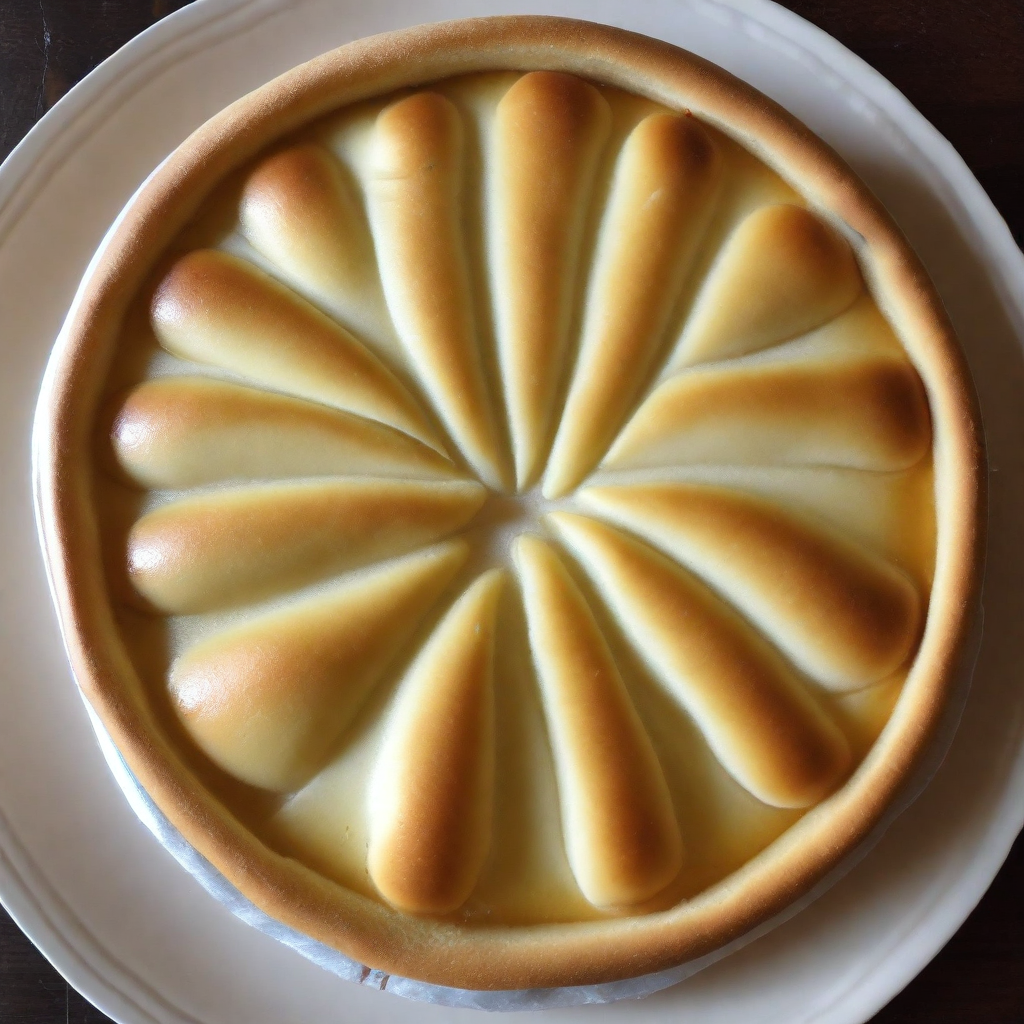

In [6]:
###################### hyper-paramters ######################
batch_size = 32
alpha = 80
total_steps = 30
max_inner_steps = 10
num_inference_steps = 8
guidance_scale = 0.0
# dimension = pipe.unet.config.in_channels * pipe.unet.config.sample_size * pipe.unet.config.sample_size
dimension = 1024
self_improvement_ratio = 0.5
reward_scaling_factor = 100
initial_step_size = 30
decay_rate = 0.1  # 调整衰减率
###################### hyper-paramters ######################
is_train = False
# prompt = 'A yellow reindeer and a blue elephant.'
prompt = ''
########################### utils ###########################
@torch.inference_mode()
def latents_to_images(latents):
    shift_factor = pipe.vae.config.shift_factor if pipe.vae.config.shift_factor else 0.0
    latents = (latents / pipe.vae.config.scaling_factor) + shift_factor
    images = pipe.vae.decode(latents, return_dict=False)[0]
    images = pipe.image_processor.postprocess(images)
    return images

def x_flatten(x):
    return einops.rearrange(x, '... C W H -> ... (C W H)', C=pipe.unet.config.in_channels, W=pipe.unet.config.sample_size, H=pipe.unet.config.sample_size)
def x_unflatten(x):
    return einops.rearrange(x, '... (C W H) -> ... C W H', C=pipe.unet.config.in_channels, W=pipe.unet.config.sample_size, H=pipe.unet.config.sample_size)
def get_norm(epsilon):
    return x_flatten(epsilon).norm(dim=-1)[:,:,None,None,None]
def merge_images_grid(image_grid):
    # Assuming image_grid is a 2D list: [[img00, img01, ...], [img10, img11, ...], ...]
    rows = len(image_grid)
    cols = len(image_grid[0])

    # Assume all images are the same size
    img_width, img_height = image_grid[0][0].size

    # Create a new blank image with correct total size
    merged_image = Image.new('RGB', (cols * img_width, rows * img_height))

    for row_idx, row in enumerate(image_grid):
        for col_idx, img in enumerate(row):
            merged_image.paste(img, (col_idx * img_width, row_idx * img_height))

    return merged_image

generator = torch.Generator(device="cuda").manual_seed(0)
########################### utils ###########################


pseudo_target_model = PseudoTargetModel(dimension=dimension, noise_level=1e-4)
pseudo_target_model = pseudo_target_model.to("cuda")

generate_batch_size = 3
save_per = 5
data = torch.load("/home/ldy/Closed_loop_optimizing/data/pseudo_train_data/open_clip/clip_embed_tar/00014_bike_data_scaling.pth")
data = torch.load("/home/ldy/Closed_loop_optimizing/data/pseudo_train_data/open_clip/clip_embed_tar/00135_pie_data_scaling.pth")
data_x, data_y = data["data_x"].to(device), data["data_y"].to(device)
tar_image_embed = torch.load("/home/ldy/Closed_loop_optimizing/data/clip_embed/open_clip/00014_bike_image_embeds.pt", map_location=device)
tar_image_embed = torch.load("/home/ldy/Closed_loop_optimizing/data/clip_embed/open_clip/00135_pie_image_embeds.pt", map_location=device)


# pseudo_target_model.add_model_data(x_flatten(data_x), data_y)
pseudo_target_model.add_model_data(data_x, data_y)

epsilon = torch.randn(num_inference_steps+1, generate_batch_size, pipe.unet.config.in_channels, pipe.unet.config.sample_size, pipe.unet.config.sample_size, device="cuda", generator=generator)
# base_latents = vae_latents[0].unsqueeze(0).expand(generate_batch_size, *vae_latents[0].shape).type(torch.bfloat16).to(device)
# base_latents = base_latents.unsqueeze(0).expand(num_inference_steps+1, *base_latents.shape)
# noise = torch.randn(base_latents.shape, generator=generator, device=device, dtype=torch.bfloat16)
# epsilon = base_latents + epsilon + noise

epsilon_init = epsilon.clone()
epsilon_init_norm = get_norm(epsilon_init)
all_images = []
# print(f"epsilon {epsilon[1:].shape}")
pipe.load_ip_adapter(
    "h94/IP-Adapter", subfolder="sdxl_models", 
    weight_name="ip-adapter_sdxl_vit-h.bin", 
    torch_dtype=torch.bfloat16)
pipe.set_ip_adapter_scale(0.5)

# pseudo_target = torch.randn(num_inference_steps+1, generate_batch_size, 1024, device="cuda", generator=generator)
pseudo_target = torch.randn(generate_batch_size, 1024, device="cuda", generator=generator)
# pseudo_target = img_embeds[0].unsqueeze(0).expand(generate_batch_size, 1024)

for step in range(total_steps):
    # if step==0:
    #     latents = vae_latents[0].unsqueeze(0).expand(generate_batch_size, *vae_latents[0].shape).type(torch.bfloat16).to(device)
        # noise = torch.randn(latents.shape, generator=generator, device=device, dtype=torch.bfloat16)
        # print("noise", noise.shape)
        # latents = latents + noise
        
        # latents = pipe(
        #     [prompt]*generate_batch_size,
        #     # ip_adapter_image_embeds = [img_embeds[0:1].unsqueeze(1).type(torch.bfloat16).to(device)],
        #     latents=vae_latents[0].unsqueeze(0).expand(generate_batch_size, *vae_latents[0].shape).type(torch.bfloat16),
        #     given_noise=epsilon[1:].type(torch.bfloat16),
        #     output_type="latent",
        #     num_inference_steps=num_inference_steps,
        #     guidance_scale=guidance_scale,
        #     eta=1.0,
        # ).images
    # else:
    latents = pipe(
        [prompt]*generate_batch_size,
        # ip_adapter_image_embeds = [img_embeds[0:1].unsqueeze(1).type(torch.bfloat16).to(device)],
        ip_adapter_image_embeds = [pseudo_target.unsqueeze(0).type(torch.bfloat16).to(device)],
        latents=epsilon[0].type(torch.bfloat16),
        given_noise=epsilon[1:].type(torch.bfloat16),
        output_type="latent",
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        eta=1.0,
        ).images
    
    
    images = latents_to_images(latents)    
    image_inputs = torch.stack([preprocess_train(img) for img in images])    
    with torch.no_grad():
        image_features = vlmodel.encode_image(image_inputs.to(device))
    
    scaled_similarity = reward_function_clip_embed(image_features, tar_image_embed.expand(generate_batch_size, 1024)) * reward_scaling_factor    
    step_size = initial_step_size / (1 + decay_rate * step)    
    pseudo_target = pseudo_target_model.estimate_pseudo_target(image_features, step_size=step_size)        
    
    # pseudo_target = x_unflatten(pseudo_target)

    # epsilon_hat = epsilon + alpha * (pseudo_target - latents)
    # epsilon = epsilon_hat / get_norm(epsilon_hat) * epsilon_init_norm
    
    # if step > self_improvement_ratio * total_steps:
    #     pseudo_target_model.add_model_data(image_features, -scaled_similarity)
        
    if step % save_per == 0:
        print(f"scaled_similarity {scaled_similarity}")
        all_images.append(images)

merged_image = merge_images_grid(all_images)
merged_image.save("/home/ldy/Closed_loop_optimizing/plots/Heuristic_generation/output.jpg")

display(images[0])